In [ ]:
from google.colab import files
uploaded = files.upload()


Saving heart_attack_prediction_dataset.csv.zip to heart_attack_prediction_dataset.csv.zip


In [ ]:
import os
os.listdir()


['.config', 'heart_attack_prediction_dataset.csv.zip', 'sample_data']

In [ ]:
import os
import zipfile

os.rename("heart_attack_prediction_dataset.csv.zip", "heart_data.zip")

with zipfile.ZipFile("heart_data.zip", 'r') as zip_ref:
    zip_ref.extractall("heart_data")

os.listdir("heart_data")


['heart_attack_prediction_dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("heart_data/heart_attack_prediction_dataset.csv")
df.head()


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
import os
os.listdir('/content')


['.config', 'heart_data', 'heart_data.zip', 'sample_data']

In [ ]:
os.listdir('/content/heart_data')


['heart_attack_prediction_dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/heart_data/heart_attack_prediction_dataset.csv')

df.head()


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
df.isnull().sum()

df.dtypes


,0
Patient ID,object
Age,int64
Sex,object
Cholesterol,int64
Blood Pressure,object
Heart Rate,int64
Diabetes,int64
Family History,int64
Smoking,int64
Obesity,int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Sex', 'Blood Pressure', 'Diet', 'Country', 'Continent', 'Hemisphere']
encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])


In [ ]:
X = df.drop(['Patient ID', 'Heart Attack Risk'], axis=1)
y = df['Heart Attack Risk']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6400456360524814
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.98      0.78      1125
           1       0.46      0.03      0.05       628

    accuracy                           0.64      1753
   macro avg       0.55      0.50      0.41      1753
weighted avg       0.58      0.64      0.52      1753



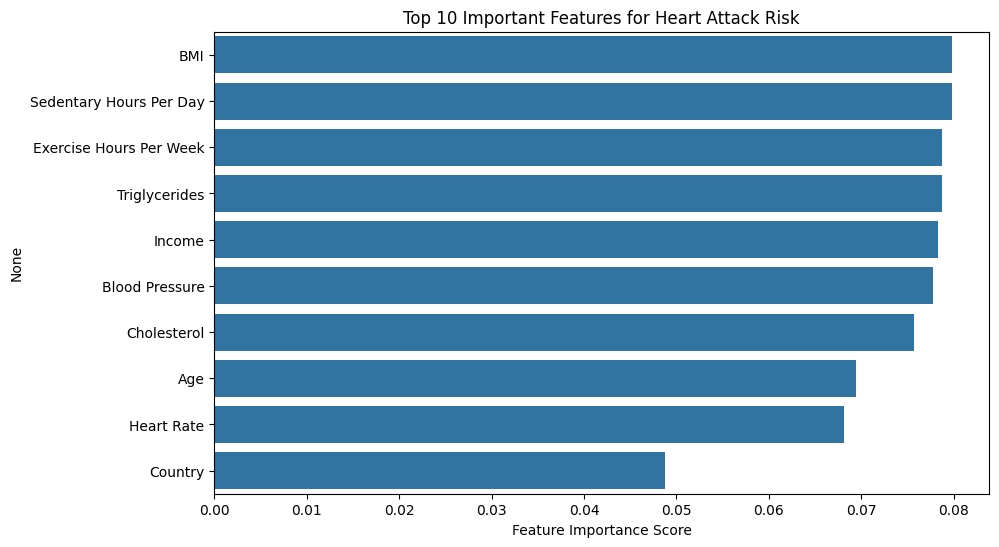

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False)[:10]

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 10 Important Features for Heart Attack Risk")
plt.xlabel("Feature Importance Score")
plt.show()


In [ ]:
df['Heart Attack Risk'].value_counts()


,count
Heart Attack Risk,
0,5624
1,3139


In [ ]:
!pip install -U imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df.drop("Heart Attack Risk", axis=1)
y = df["Heart Attack Risk"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts())


ValueError: could not convert string to float: 'RCA7696'

In [ ]:
X = df.drop(["Heart Attack Risk", "Patient ID", "Country", "Continent", "Hemisphere"], axis=1)
y = df["Heart Attack Risk"]


In [ ]:
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_res, y_train_res)

from sklearn.metrics import classification_report, accuracy_score
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5675984027381632
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.76      0.69      1125
           1       0.34      0.22      0.26       628

    accuracy                           0.57      1753
   macro avg       0.49      0.49      0.48      1753
weighted avg       0.53      0.57      0.54      1753



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           scoring='accuracy',
                           verbose=2)

grid_search.fit(X_train_res, y_train_res)

best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

y_pred = best_rf.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned Classification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Accuracy: 0.5755847119224187
Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.77      0.70      1125
           1       0.36      0.23      0.28       628

    accuracy                           0.58      1753
   macro avg       0.50      0.50      0.49      1753
weighted avg       0.54      0.58      0.55      1753



In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_res, y_train_res)
y_pred_lr = logreg.predict(X_test)

print("LogReg Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


LogReg Accuracy: 0.49743297204791787
              precision    recall  f1-score   support

           0       0.62      0.55      0.58      1125
           1       0.33      0.41      0.37       628

    accuracy                           0.50      1753
   macro avg       0.48      0.48      0.48      1753
weighted avg       0.52      0.50      0.51      1753



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=2000)
logreg.fit(X_train_scaled, y_train_res)

y_pred_lr = logreg.predict(X_test_scaled)
print("LogReg Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


LogReg Accuracy: 0.5185396463205932
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      1125
           1       0.34      0.38      0.36       628

    accuracy                           0.52      1753
   macro avg       0.49      0.49      0.49      1753
weighted avg       0.53      0.52      0.52      1753



In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:04:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.5464917284654878
              precision    recall  f1-score   support

           0       0.64      0.67      0.65      1125
           1       0.36      0.33      0.34       628

    accuracy                           0.55      1753
   macro avg       0.50      0.50      0.50      1753
weighted avg       0.54      0.55      0.54      1753



In [ ]:
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb_model, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best_xgb = best_model.predict(X_test)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print(classification_report(y_test, y_pred_best_xgb))


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:08:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Tuned XGBoost Accuracy: 0.5647461494580719
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      1125
           1       0.37      0.30      0.33       628

    accuracy                           0.56      1753
   macro avg       0.51      0.51      0.51      1753
weighted avg       0.55      0.56      0.55      1753

